练习数据来源:https://kaggle.com

In [1]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/medical-insurance-cost-prediction")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\www12\.cache\kagglehub\datasets\mohankrishnathalla\medical-insurance-cost-prediction\versions\1


In [2]:
import pandas as pd

# 加载数据的函数
def load_medical_data(path):
    return pd.read_csv(path)

medical = load_medical_data("./datasets/kaggle/mohankrishnathalla/medical_insurance.csv")

# 1. 快速浏览数据结构

In [3]:
medical.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [4]:
medical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

In [7]:
medical.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


为每个属性绘制直方图

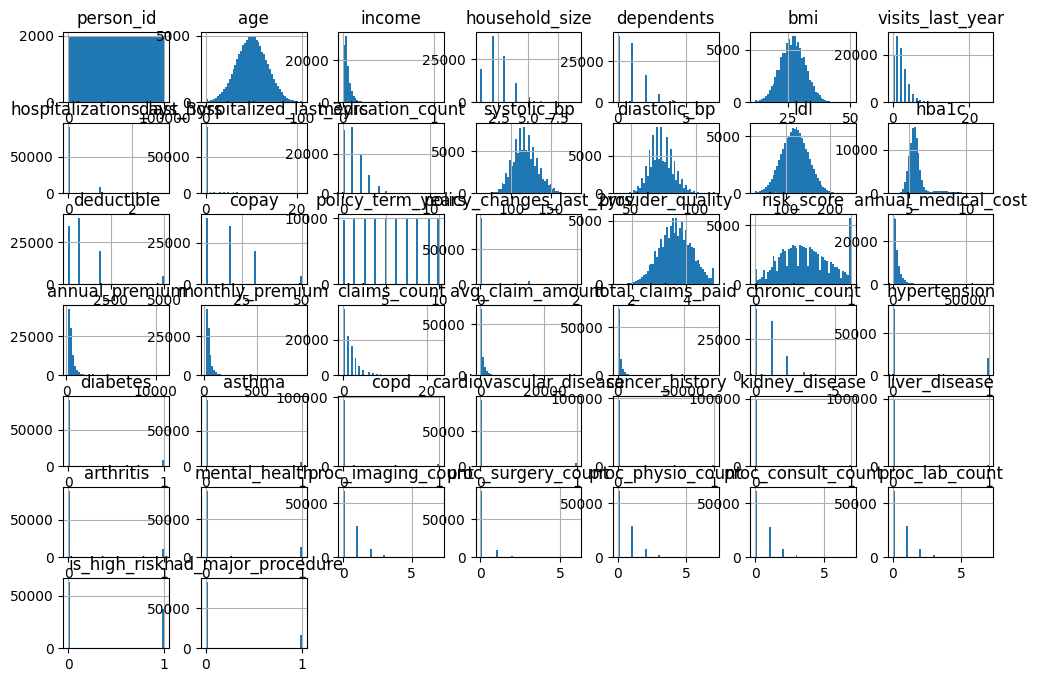

In [8]:
import matplotlib.pyplot as plt

plt.style.use("default")

medical.hist(bins=50, figsize=(12,8))
plt.show()

# 2. 创建测试集

## 方式1：根据datasets长度做索引打乱进行一次性划分
采用np.random.permutation()

In [9]:
import numpy as np

np.random.seed(42)

# 构建打乱与切分数据的函数
def shuffle_and_split_data(data, test_ratio):

    assert 0 < test_ratio < 1

    shuffled_indices = np.random.permutation(len(data)) # 生成0~n-1的随机排列数组
    test_set_size = int(len(data) * test_ratio)

    test_indices = shuffled_indices[:test_set_size] # 取前test_set_size个索引
    train_indices = shuffled_indices[test_set_size:] # 取剩余的索引

    return data.iloc[train_indices], data.iloc[test_indices]

In [10]:
# 使用shuffle_and_split_data函数
train_set, test_set = shuffle_and_split_data(data=medical, test_ratio=0.2)

print("Train set size: ", len(train_set))
print("Test set size: ", len(test_set))

Train set size:  80000
Test set size:  20000


In [11]:
# 查看训练集
train_set.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
75220,72823,73,Female,West,Rural,67700.0,Bachelors,Married,Employed,2,...,0,0,0,1,0,1,0,1,1,0
48955,45561,43,Female,East,Urban,90200.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,2,0,0
44966,27616,70,Male,North,Rural,64200.0,HS,Married,Employed,2,...,0,0,0,2,0,0,0,0,1,0
13568,5174,32,Female,North,Urban,26000.0,Bachelors,Married,Retired,2,...,0,0,0,0,0,1,0,0,0,0
92727,18101,33,Male,South,Urban,32100.0,Bachelors,Married,Retired,3,...,0,0,0,1,0,0,0,1,0,0


## 方式2：采用crc32方式计算hash值以划分数据集

In [14]:
from zlib import crc32

# 判断id是否进入测试集
def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

# 用哈希规则划分数据集
def split_data_with_id_hash(data, test_ratio, id_column):

    ids = data[id_column]
    print("type_ids" + str(type(ids)))
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))

    return data.loc[~in_test_set], data.loc[in_test_set]

In [15]:
train_set, test_set = split_data_with_id_hash(data=medical, test_ratio=0.2, id_column="person_id")
print("Train set size: ", len(train_set))
print("Test set size: ", len(test_set))

type_ids<class 'pandas.core.series.Series'>
Train set size:  80000
Test set size:  20000


In [17]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    80000 non-null  int64  
 1   age                          80000 non-null  int64  
 2   sex                          80000 non-null  object 
 3   region                       80000 non-null  object 
 4   urban_rural                  80000 non-null  object 
 5   income                       80000 non-null  float64
 6   education                    80000 non-null  object 
 7   marital_status               80000 non-null  object 
 8   employment_status            80000 non-null  object 
 9   household_size               80000 non-null  int64  
 10  dependents                   80000 non-null  int64  
 11  bmi                          80000 non-null  float64
 12  smoker                       80000 non-null  object 
 13  alcohol_freq         

In [18]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 1 to 99995
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    20000 non-null  int64  
 1   age                          20000 non-null  int64  
 2   sex                          20000 non-null  object 
 3   region                       20000 non-null  object 
 4   urban_rural                  20000 non-null  object 
 5   income                       20000 non-null  float64
 6   education                    20000 non-null  object 
 7   marital_status               20000 non-null  object 
 8   employment_status            20000 non-null  object 
 9   household_size               20000 non-null  int64  
 10  dependents                   20000 non-null  int64  
 11  bmi                          20000 non-null  float64
 12  smoker                       20000 non-null  object 
 13  alcohol_freq         

## 方式3：利用数据特性构建id再构建hash值以划分数据集
* 未看清数据特性，故暂不写

## 方式4：利用`train_test_split()`函数

In [25]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(medical, test_size=0.2, random_state=42)

In [27]:
len(train_set)

80000

## 方式5：利用`model_selection`包的拆分函数